<a href="https://colab.research.google.com/github/Taran-Gupta/DS4002_Project2/blob/main/Scripts/Unemployment_and_Net_Worth_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Reading the files in.
unemployment = pd.read_csv("../Data/unemployment_cleaned.csv", index_col = 0)
net_worth = pd.read_csv("../Data/net_worth_cleaned.csv", index_col = 0)

In [3]:
# Combining them into one dataframe

unemployment.index = pd.to_datetime(unemployment.index)
net_worth.index = pd.to_datetime(net_worth.index)

combined = unemployment.join(net_worth, lsuffix = "unemp", rsuffix = "networth")

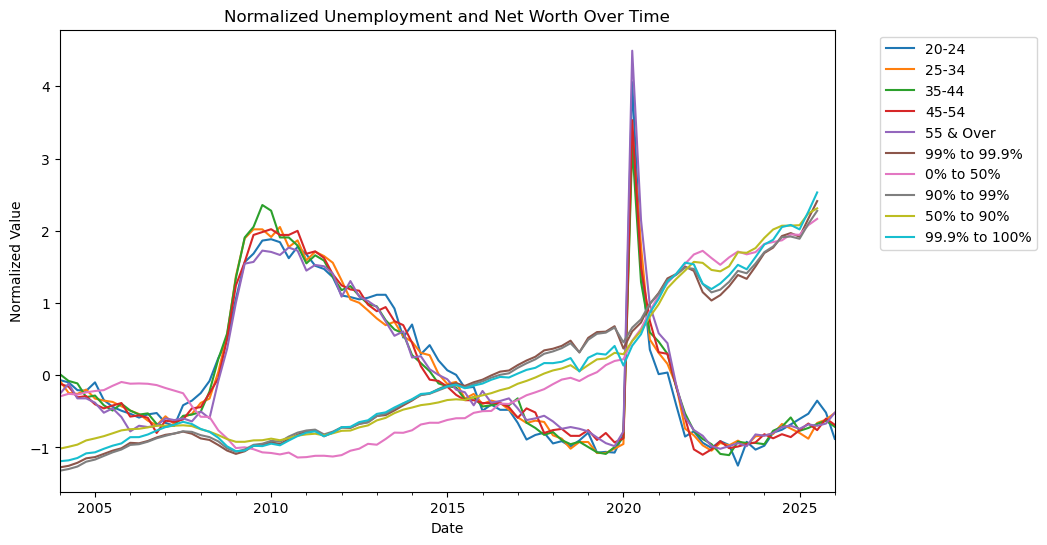

In [24]:
# Unemployment and net worth values are different, so it is best to normalize them before visualizing.

#Normalizing
normalized = (combined.select_dtypes(include = "number") - combined.select_dtypes(include = "number").mean()) / combined.select_dtypes(include = "number").std()

normalized.plot(figsize = (10,6))
plt.legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0))
plt.title("Normalized Unemployment and Net Worth Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.show()

In [13]:
# Pearson correlation coefficient
#Creating correlation matrix for unemployment and net worth.
correlation_matrix = combined.select_dtypes(include = "number").corr(method='pearson')
print(correlation_matrix)

                  20-24     25-34     35-44     45-54  55 & Over  \
20-24          1.000000  0.983165  0.977490  0.981179   0.973886   
25-34          0.983165  1.000000  0.991733  0.992089   0.977905   
35-44          0.977490  0.991733  1.000000  0.990668   0.970394   
45-54          0.981179  0.992089  0.990668  1.000000   0.981768   
55 & Over      0.973886  0.977905  0.970394  0.981768   1.000000   
99% to 99.9%  -0.452916 -0.454238 -0.457787 -0.443542  -0.357463   
0% to 50%     -0.555665 -0.559596 -0.557342 -0.562574  -0.485655   
90% to 99%    -0.444164 -0.445036 -0.449028 -0.434674  -0.348602   
50% to 90%    -0.460880 -0.462074 -0.462837 -0.459609  -0.381482   
99.9% to 100% -0.457813 -0.461290 -0.463645 -0.456061  -0.375468   

               99% to 99.9%  0% to 50%  90% to 99%  50% to 90%  99.9% to 100%  
20-24             -0.452916  -0.555665   -0.444164   -0.460880      -0.457813  
25-34             -0.454238  -0.559596   -0.445036   -0.462074      -0.461290  
35-44      

In [14]:
correlation_matrix.loc[unemployment.columns, net_worth.columns]

,99% to 99.9%,0% to 50%,90% to 99%,50% to 90%,99.9% to 100%
20-24,-0.452916,-0.555665,-0.444164,-0.460880,-0.457813
25-34,-0.454238,-0.559596,-0.445036,-0.462074,-0.461290
35-44,-0.457787,-0.557342,-0.449028,-0.462837,-0.463645
45-54,-0.443542,-0.562574,-0.434674,-0.459609,-0.456061
55 & Over,-0.357463,-0.485655,-0.348602,-0.381482,-0.375468


In [16]:
# Combining all unemployment and net worth by taking mean across groups.

unemp_series = unemployment.select_dtypes(include="number").mean(axis=1)

networth_series = net_worth.select_dtypes(include="number").mean(axis=1)

pearson_corr = unemp_series.corr(networth_series, method="pearson")
print(pearson_corr)  # Correlation coefficient is -.448. This is based on raw levels.

-0.44895723426356354


In [17]:
#Combining the series for rolling correlation

combined_series = pd.concat([unemp_series, networth_series], axis=1).dropna()
combined_series.columns = ["unemp", "networth"]

In [ ]:
# Taking percentage change for each column

combined_series["unemp_change"] = combined_series["unemp"].diff()
combined_series["networth_change"] = combined_series["networth"].pct_change()

# Doing pearson correlation again but measuring change.
pearson_corr_diff = unemp_series.diff().corr(networth_series.pct_change(), method="pearson")
print(pearson_corr_diff)

0.02211159180200213


In [ ]:
# Looking at top .1%

top1_networth = net_worth["99.9% to 100%"]

pearson_top1 = unemp_series.diff().corr(top1_networth.pct_change(), method="pearson")
print(pearson_top1)

0.03510551823806457


In [22]:
# Rolling correlation with window of 2 years.
rolling_corr = combined_series["unemp_change"].rolling(8).corr(combined_series["networth_change"])

pd.set_option('display.max_rows', None) # display all rows
print(rolling_corr)

observation_date
2004-01-01         NaN
2004-04-01         NaN
2004-07-01         NaN
2004-10-01         NaN
2005-01-01         NaN
2005-04-01         NaN
2005-07-01         NaN
2005-10-01         NaN
2006-01-01   -0.053409
2006-04-01   -0.223587
2006-07-01   -0.308944
2006-10-01   -0.598209
2007-01-01   -0.619243
2007-04-01   -0.551604
2007-07-01   -0.497266
2007-10-01   -0.536849
2008-01-01   -0.511731
2008-04-01   -0.622668
2008-07-01   -0.754570
2008-10-01   -0.809526
2009-01-01   -0.650440
2009-04-01   -0.224918
2009-07-01   -0.244240
2009-10-01   -0.299872
2010-01-01   -0.545443
2010-04-01   -0.489866
2010-07-01   -0.580096
2010-10-01   -0.581570
2011-01-01   -0.059619
2011-04-01    0.039862
2011-07-01   -0.086545
2011-10-01   -0.101879
2012-01-01   -0.292860
2012-04-01   -0.314576
2012-07-01   -0.292131
2012-10-01   -0.531570
2013-01-01   -0.383688
2013-04-01   -0.366227
2013-07-01   -0.382401
2013-10-01   -0.431292
2014-01-01   -0.408443
2014-04-01   -0.057449
2014-07-01   -0.2

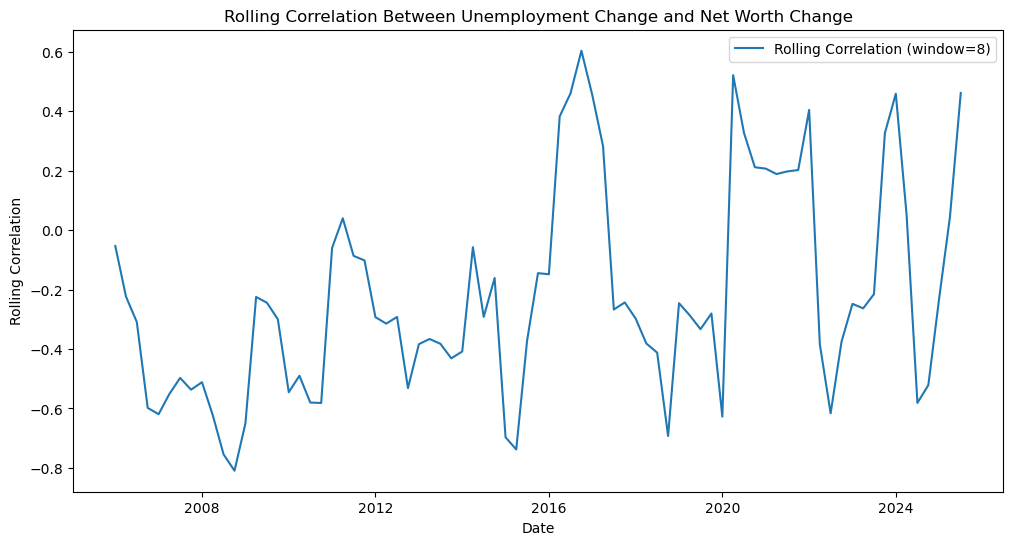

In [23]:
# create rolling correlation plot
plt.figure(figsize=(12, 6))
plt.plot(rolling_corr.index, rolling_corr, label='Rolling Correlation (window=8)')
plt.title('Rolling Correlation Between Unemployment Change and Net Worth Change')
plt.xlabel('Date')
plt.ylabel('Rolling Correlation')
plt.legend()
plt.show()